# Pandas Tutorial


---



This notebook serves as an introduction to the essential data structures offered by the **Pandas** library, a cornerstone tool in the Python data science ecosystem.

Built on top of NumPy, Pandas provides a highly efficient and flexible implementation of **DataFrames**—two-dimensional, labeled data structures that support heterogeneous data types and gracefully handle missing values. These DataFrames enable powerful data manipulation capabilities through intuitive and high-level operations.

Throughout this notebook, we will use the standard alias `pd` when importing Pandas.


In [3]:
import pandas as pd
import numpy as np

## Pandas Series


A Pandas `Series` is a one-dimensional array of indexed data.

In [4]:
data = pd.Series([0.25, 0.5, 0.75, 1.0])
data

0    0.25
1    0.50
2    0.75
3    1.00
dtype: float64

The contents can be accessed in the same way as for NumPy arrays, to the difference that when more than one value is selected, the type remains a Pandas ``Series``.

In [5]:
print(data[0],type(data[0]))

0.25 <class 'numpy.float64'>


In [6]:
print(data[2:],type(data[2:]))

2    0.75
3    1.00
dtype: float64 <class 'pandas.Series'>


The type ``Series`` wraps both a sequence of values and a sequence of indices, which we can access with the <tt>values</tt> and <tt>index</tt> attributes.

* ``values`` are the contents of the series as a NumPy array

In [7]:
print(data.values,type(data.values))

[0.25 0.5  0.75 1.  ] <class 'numpy.ndarray'>


* ``index`` are the indices of the series

In [8]:
print(data.index,type(data.index))

RangeIndex(start=0, stop=4, step=1) <class 'pandas.RangeIndex'>


### Series Indices

The main difference between NumPy arrays and Pandas Series is the presence of this <tt>index</tt> field. By default, it is set (as in NumPy arrays) as <tt>0,1,..,size_of_the_series</tt> but a Series index can be explicitly defined. The indices may be numbers but also strings. Then, the contents of the series *have to* be accessed using these defined indices.

In [9]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=['a', 'b', 'c', 'd'])
print(data)

a    0.25
b    0.50
c    0.75
d    1.00
dtype: float64


In [10]:
print(data['c'])

0.75


In [11]:
data = pd.Series([0.25, 0.5, 0.75, 1.0], index=[1, 3, 4, 2])
print(data)

1    0.25
3    0.50
4    0.75
2    1.00
dtype: float64


In [12]:
print(data[2])

1.0


### Series and Python Dictionaries

Pandas Series and Python Dictionaries are close semantically: mappping keys to values. However, the implementation of Pandas series is usually more efficient than dictionaries in the context of data science. Naturally, Series can be contructed from dictionaries.

In [13]:
population_dict = {'California': 38332521,
                   'Texas': 26448193,
                   'New York': 19651127,
                   'Florida': 19552860,
                   'Illinois': 12882135}
population = pd.Series(population_dict)
print(population_dict,type(population_dict))
print(population,type(population))

{'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135} <class 'dict'>
California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.Series'>


In [14]:
population['California']

np.int64(38332521)

In [15]:
population['California':'Illinois']

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64

## Pandas DataFrames

DataFrames is a fundamental object of Pandas that mimicks what can be found in `R` for instance. Dataframes can be seen as an array of Series: to each `index` (corresponding to an individual for instance or a line in a table), a Dataframe maps multiples values; these values corresponds to the `columns` of the DataFrame which each have a name (as a string).   


In the following example, we will construct a Dataframe from two Series with common indices.

In [16]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})

In [17]:
states = pd.DataFrame({'Population': population, 'Area': area})
print(states,type(states))

            Population    Area
California    38332521  423967
Texas         26448193  695662
New York      19651127  141297
Florida       19552860  170312
Illinois      12882135  149995 <class 'pandas.DataFrame'>


In Jupyter notebooks, DataFrames are displayed in a fancier way when the name of the dataframe is typed (instead of using <tt>print</tt>)

In [18]:
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


DataFrames have
* <tt>index</tt> that are the defined indices as in Series
* <tt>columns</tt> that are the columns names
* <tt>values</tt> that return a (2D) NumPy array with the contents

In [19]:
print(states.index)
print(states.columns)
print(states.values,type(states.values),states.values.shape)

Index(['California', 'Texas', 'New York', 'Florida', 'Illinois'], dtype='str')
Index(['Population', 'Area'], dtype='str')
[[38332521   423967]
 [26448193   695662]
 [19651127   141297]
 [19552860   170312]
 [12882135   149995]] <class 'numpy.ndarray'> (5, 2)


*Warning:*  When accessing a Dataframe, `dataframe_name[column_name]` return the corresponding column as a Series. `dataframe_name[index_name]` returns an error! We will see later how to access a specific index.

In [20]:
print(states['Area'],type(states['Area']))

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64 <class 'pandas.Series'>


In [21]:
try:
    print(states['California'])
except KeyError as error:
    print("KeyError: ",error)

KeyError:  'California'


### Dataframe creation

To create DataFrames, the main methods are:
* from Series (as above)

In [22]:
print(population,type(population))
states = pd.DataFrame({'Population': population, 'Area': area})
states

California    38332521
Texas         26448193
New York      19651127
Florida       19552860
Illinois      12882135
dtype: int64 <class 'pandas.Series'>


,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


* from NumPy arrays (the columns and indices are taken as the array's ones)

In [23]:
A = np.random.randn(5,3)
print(A,type(A))
dfA = pd.DataFrame(A)
dfA

[[-0.38672753  0.47460878 -0.3020894 ]
 [-1.48031447  0.90763105 -1.83367287]
 [ 1.63342368  0.37153476 -1.18270952]
 [ 0.54933629 -0.10329715 -0.74930203]
 [-0.12742601 -0.15094098 -1.02187275]] <class 'numpy.ndarray'>


,0,1,2
0,-0.386728,0.474609,-0.302089
1,-1.480314,0.907631,-1.833673
2,1.633424,0.371535,-1.182710
3,0.549336,-0.103297,-0.749302
4,-0.127426,-0.150941,-1.021873


* from a *list* of *dictionaries*. Be careful, each element of the list is an example (corresponding to an automatic index 0,1,...) while each key of the dictonary corresponds to a column.

In [24]:
data = [{'a': i, 'b': 2 * i} for i in range(3)]
print(data,type(data))
print(data[0],type(data[0]))

[{'a': 0, 'b': 0}, {'a': 1, 'b': 2}, {'a': 2, 'b': 4}] <class 'list'>
{'a': 0, 'b': 0} <class 'dict'>


In [25]:
df = pd.DataFrame(data)
df

,a,b
0,0,0
1,1,2
2,2,4


* from a *file* , typically a <tt>csv</tt> file (for comma separated values), eventually with the names of the columns as a first line.


    col_1_name,col_2_name,col_3_name
    col_1_v1,col_2_v1,col_3_v1
    col_1_v2,col_2_v2,col_3_v2
    ...
    
For other files types (MS Excel, libSVM, any other separator) see this [part of the doc](https://pandas.pydata.org/pandas-docs/stable/api.html#input-output)

In [26]:
# !head -4 data/president_heights.csv # bash command to see the first 4 lines of the file

In [27]:
data = pd.read_csv('data/president_heights.csv')
data

,order,name,height(cm)
0,1,George Washington,189
1,2,John Adams,170
2,3,Thomas Jefferson,189
3,4,James Madison,163
4,5,James Monroe,183
5,6,John Quincy Adams,171
6,7,Andrew Jackson,185
7,8,Martin Van Buren,168
8,9,William Henry Harrison,173
9,10,John Tyler,183


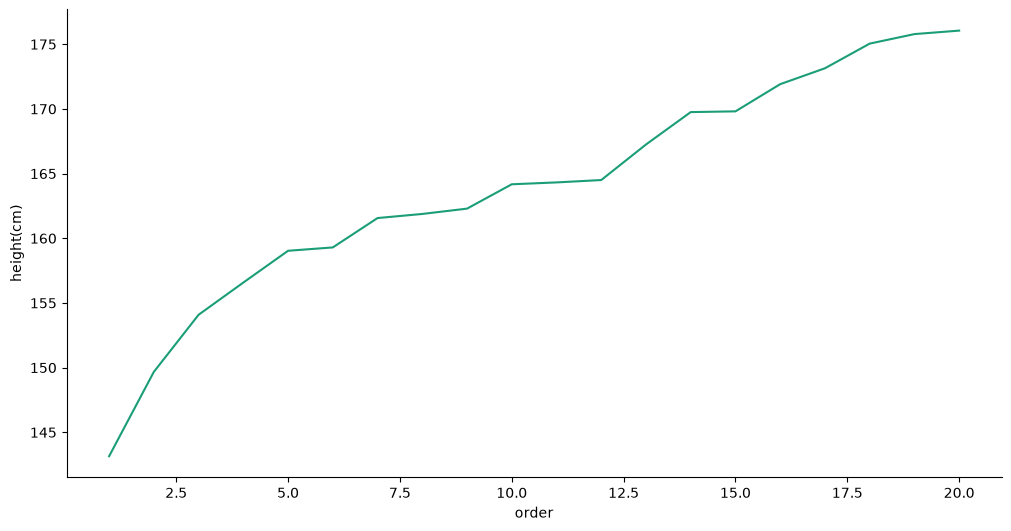

In [28]:
# @title order vs height(cm)

from matplotlib import pyplot as plt
import seaborn as sns
data = pd.DataFrame(
    {"order": np.arange(1, 21), "height(cm)": np.sort(np.random.normal(165, 10, 20))}
)
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['order']
  ys = series['height(cm)']

  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = data.sort_values('order', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('order')
_ = plt.ylabel('height(cm)')

### Names and Values

Notice there can be missing values in DataFrames.

In [29]:
pd.DataFrame([{'a': 1, 'b': 2}, {'b': 3, 'c': 4}])

,a,b,c
0,1.0,2,NaN
1,NaN,3,4.0


You can set indices and columns names *a posteriori*

In [30]:
dfA.columns = ['a','b','c']
dfA.index = [i**2 for i in range(1,6)  ]
dfA

,a,b,c
1,-0.386728,0.474609,-0.302089
4,-1.480314,0.907631,-1.833673
9,1.633424,0.371535,-1.182710
16,0.549336,-0.103297,-0.749302
25,-0.127426,-0.150941,-1.021873


## Indexing




In [31]:
area = pd.Series( {'California': 423967, 'Texas': 695662, 'New York': 141297, 'Florida': 170312, 'Illinois': 149995})
population = pd.Series({'California': 38332521, 'Texas': 26448193, 'New York': 19651127, 'Florida': 19552860, 'Illinois': 12882135})
states = pd.DataFrame({'Population': population, 'Area': area})
states

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


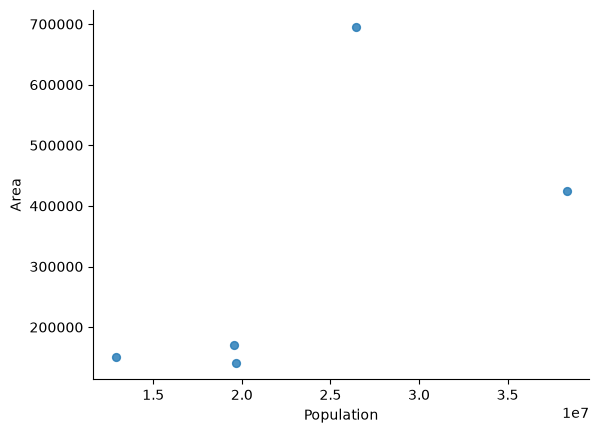

In [32]:
# @title Population vs Area

from matplotlib import pyplot as plt
states.plot(kind='scatter', x='Population', y='Area', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

You may access columns directly with names, *then* you can access individuals with their index.

In [33]:
states['Area']

California    423967
Texas         695662
New York      141297
Florida       170312
Illinois      149995
Name: Area, dtype: int64

In [34]:
states['Area']['Texas']

np.int64(695662)

To ease the access, Pandas offers dedicated methods:
* <tt>iloc</tt> enables to access subparts of the dataframe as if it was a NumPy array.

In [39]:
states.iloc[:2]

,Population,Area
California,38332521,423967
Texas,26448193,695662


In [40]:
states.iloc[:2,0]

California    38332521
Texas         26448193
Name: Population, dtype: int64

* <tt>loc</tt> does the same but with the explicit names (the last one is included)

In [41]:
states.loc[:'New York']

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297


In [42]:
states.loc[:,'Population':]

,Population,Area
California,38332521,423967
Texas,26448193,695662
New York,19651127,141297
Florida,19552860,170312
Illinois,12882135,149995


## Questions and Exercises

**1. Series:**
   - Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
   - Access the third element of the Series.
   - What is the data type of the Series?

**2. DataFrames:**
   - Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
   - Add three rows to the DataFrame with the following data:
     - Name: 'Alice', Age: 25
     - Name: 'Bob', Age: 30
     - Name: 'Charlie', Age: 35
   - Access the 'Age' column of the DataFrame.
   - What is the shape of the DataFrame?

**3. Indexing:**
   - Using the DataFrame from question 2, access the row with the name 'Bob' using `loc`.
   - Access the age of 'Alice' using `iloc`.

**4. File I/O:**
   - Read the 'president_heights.csv' file into a DataFrame.
   - What is the average height of the presidents?
   - What is the name of the tallest president?

**5. Advanced:**
   - Create a DataFrame with three columns: 'A', 'B', and 'C'.
   - Fill the DataFrame with random numbers.
   - Calculate the mean of each column.
   - Add a new column 'D' which is the sum of columns 'A' and 'B'.
   - Sort the DataFrame by column 'D' in descending order.

In [49]:
# 1. Series:

# Create a Pandas Series with the following data: [10, 20, 30, 40, 50].
pd_series = pd.Series([10, 20, 30, 40, 50]) # Created
# Access the third element of the Series.
print(f'3rd and index 2 element: {pd_series[2]}')
# What is the data type of the Series?
print(f' Data Type of Series Elements: {type(pd_series[2])}\n Data Type of Series itself: {type(pd_series)}')



3rd and index 2 element: 30
 Data Type of Series Elements: <class 'numpy.int64'>
 Data Type of Series itself: <class 'pandas.Series'>


In [62]:
# 2. DataFrames:

# Create a Pandas DataFrame with two columns: 'Name' and 'Age'.
# Add three rows to the DataFrame with the following data:
# Name: 'Alice', Age: 25
# Name: 'Bob', Age: 30
# Name: 'Charlie', Age: 35
df = pd.DataFrame({'Name':pd.Series(['Alice','Bob','Charlie']),'Age':pd.Series([25,30,35])})
print(df)
# Access the 'Age' column of the DataFrame.
print(f'Access DataFrame Age:\n{df['Age']}')
# What is the shape of the DataFrame?
print(f'DataFrame Shape: {df.shape}')

      Name  Age
0    Alice   25
1      Bob   30
2  Charlie   35
Access DataFrame Age:
0    25
1    30
2    35
Name: Age, dtype: int64
DataFrame Shape: (3, 2)


In [63]:
df

,Name,Age
0,Alice,25
1,Bob,30
2,Charlie,35


In [73]:
# 3. Indexing:

# Using the DataFrame from question 2, access the row with the name 'Bob' using loc.
print(f'Row with Bob: \n{df.iloc[1]}')

# Access the age of 'Alice' using iloc.
print(f'Alice age:\n{df.iloc[0][1:]}')


Row with Bob: 
Name    Bob
Age      30
Name: 1, dtype: object
Alice age:
Age    25
Name: 0, dtype: object


In [84]:
# 4. File I/O:

# Read the 'president_heights.csv' file into a DataFrame.
p_df=pd.read_csv('data/president_heights.csv')

# What is the average height of the presidents?
print(f'Average height of the presidents in cm: {p_df['height(cm)'].mean()}')

# What is the name of the tallest president?
print(f'Tallest president: {p_df.loc[p_df["height(cm)"].idxmax(), "name"]}')


Average height of the presidents in cm: 179.93023255813952
Tallest president: Abraham Lincoln


In [97]:
# 5. Advanced:

# Create a DataFrame with three columns: 'A', 'B', and 'C'.
# Fill the DataFrame with random numbers.
adf=pd.DataFrame({
    'A': pd.Series(np.random.rand(20)),
    'B': pd.Series(np.random.rand(20)),
    'C': pd.Series(np.random.rand(20))
    })
adf
# Calculate the mean of each column.
print(f'A_mean: {adf['A'].mean()}\nB_mean: {adf['B'].mean()}\nC_mean: {adf['C'].mean()}')

# Add a new column 'D' which is the sum of columns 'A' and 'B'.
adf['D']=adf['A']+adf['B']
# Sort the DataFrame by column 'D' in descending order.
sorted_adf=adf.sort_values(by="D",ascending=True)
sorted_adf

A_mean: 0.5529342402608768
B_mean: 0.6412277257544154
C_mean: 0.486365126026571


,A,B,C,D
11,0.153313,0.056842,0.297458,0.210156
8,0.184409,0.336877,0.027110,0.521287
18,0.321568,0.344572,0.284902,0.666140
12,0.177187,0.630280,0.085976,0.807467
1,0.046437,0.821709,0.788738,0.868146
17,0.328698,0.598644,0.893352,0.927342
13,0.264930,0.796259,0.947257,1.061189
4,0.658691,0.431841,0.916584,1.090532
0,0.209869,0.885902,0.649250,1.095771
3,0.989427,0.176775,0.047052,1.166201
